In [1]:
from resources.imports import *

import torch
import torch.nn as nn

from resources.MLdata import DATA
from resources.MLfunc import EarlyStopping, weights_init,\
                             CustomQuantileLoss, CustomQuantileLossMATLAB, CustomStrainEnergyLoss, CustomPhysicalRegularizationLoss
from resources.MLmodels import *

# Stress-Strain Curve

In [2]:
DAT = DATA(
    path=1, 
    path_add="",
    load=True, 
    load_split=False,
    split_frac=0.85,
    save_split=False,
    LAT="FCC", 
    dis="disNodes", 
    dN=0.2, 
    mechMode="MULTI",
    nsims=None,
    model="MLP",
    scale=("maxmin", "inout"),
    reduce_dim=False #("PCA", "out", 0.95, 10, True)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

c:\Users\exy053\OneDrive - Queen Mary, University of London\Documents\Research\p1-LatticeFractureToughness\p1git-Lattices\code\resources\lattices.py:672: RuntimeWarning: divide by zero encountered in double_scalars
  return np.array([np.cos(np.arctan([n0[1]/n0[0]]))[0], np.sin(np.arctan([n0[1]/n0[0]]))[0]])


Using device: cpu


In [3]:
if DAT.UTmechTest:
    print("UT shape:", DAT.UT_train_in.shape, DAT.UT_train_out.shape)
    print("Train -  in (min, max):", DAT.UT_train_in.min(), DAT.UT_train_in.max(), "\n        out (min, max):", DAT.UT_train_out.min(), DAT.UT_train_out.max())
    print("  Val -  in (min, max):", DAT.UT_val_in.min(), DAT.UT_val_in.max(), "\n        out (min, max):", DAT.UT_val_out.min(), DAT.UT_val_out.max())
    print(" Test -  in (min, max):", DAT.UT_test_in.min(), DAT.UT_test_in.max(), "\n        out (min, max):", DAT.UT_test_out.min(), DAT.UT_test_out.max())
    if DAT.FTmechTest: print("\n========================================================\n")
if DAT.FTmechTest:
    print("FT shape:", DAT.FT_train_in.shape, DAT.FT_train_out.shape)
    print("Train -  in (min, max):", DAT.FT_train_in.min(), DAT.FT_train_in.max(), "\n        out (min, max):", DAT.FT_train_out.min(), DAT.FT_train_out.max())
    print("  Val -  in (min, max):", DAT.FT_val_in.min(), DAT.FT_val_in.max(), "\n        out (min, max):", DAT.FT_val_out.min(), DAT.FT_val_out.max())
    print(" Test -  in (min, max):", DAT.FT_test_in.min(), DAT.FT_test_in.max(), "\n        out (min, max):", DAT.FT_test_out.min(), DAT.FT_test_out.max())

UT shape: (4893, 1444) (4893, 201)
Train -  in (min, max): 0.0 1.0 
        out (min, max): 0.0 1.0000000000000002
  Val -  in (min, max): -0.0012724542682954754 1.0013938737254562 
        out (min, max): -0.32660794367082335 1.3686904422111845
 Test -  in (min, max): -0.0013319421465492476 1.0011403570922492 
        out (min, max): -0.10710676466828861 1.016655277931977


FT shape: (4893, 1420) (4893, 201)
Train -  in (min, max): 0.0 1.0 
        out (min, max): 0.0 1.0000000000000002
  Val -  in (min, max): -0.0012724542682954754 1.0013938737254562 
        out (min, max): -0.07214104584894176 1.038675210695611
 Test -  in (min, max): -0.0013319421465492476 1.0011403570922492 
        out (min, max): -0.07387461057052014 1.1654342241314382


## Multi-Layer Perceptrion (MLP)

In [4]:
MLP1 = MODEL(
    typ=DAT.model,
    model=MLP(in_size=DAT.UT_train_in.shape[-1], 
              h_size=[2048, 1024, 1024, 1024, 512, 512], 
              out_size=DAT.UT_train_out.shape[-1], 
              act="relu",
              block="mlp",
              norm="layer", 
              dropout=0.0).to(device), 
    lossf=nn.MSELoss(reduction="mean"), #CustomQuantileLoss(quantiles=[0.5, 0.45, 0.1], zone_boundaries=(50, 150), err_type="L2"),
    opt=("adam", 0.0), #("adam", 1e-4),
    batch=16,
    lr=1e-3, #9e-4,
    data=DAT,
    mechMode=DAT.mechMode,
    scheduler=("min", 0.2427, 100, 1e-4), #("min", 0.2427, 18, 1e-4), 
    earlyStop=EarlyStopping(patience=150, min_delta=1e-4, verbose=True),
    w_init=weights_init,
    device=device
)

MLP1._summary()

Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [16, 201]                 --
├─Linear: 1-1                            [16, 2048]                2,959,360
├─LayerNorm: 1-2                         [16, 2048]                4,096
├─ReLU: 1-3                              [16, 2048]                --
├─ModuleList: 1-4                        --                        --
│    └─mlpBlock: 2-1                     [16, 1024]                --
│    │    └─Linear: 3-1                  [16, 1024]                2,098,176
│    │    └─LayerNorm: 3-2               [16, 1024]                2,048
│    │    └─ReLU: 3-3                    [16, 1024]                --
│    └─mlpBlock: 2-2                     [16, 1024]                --
│    │    └─Linear: 3-4                  [16, 1024]                1,049,600
│    │    └─LayerNorm: 3-5               [16, 1024]                2,048
│    │    └─ReLU: 3-6                    [16, 1024]    

 -> Epoch 1/1000 || LOSS - train: 0.030297, val: 0.023934 | MSE - train: 0.030304, val: 0.023934 | RMSE - train: 0.174080, val: 0.154706 | LR: 1.00e-03
 -> Epoch 20/1000 || LOSS - train: 0.019523, val: 0.023508 | MSE - train: 0.019520, val: 0.023508 | RMSE - train: 0.139714, val: 0.153322 | LR: 1.00e-03
 -> Epoch 40/1000 || LOSS - train: 0.016728, val: 0.023788 | MSE - train: 0.016731, val: 0.023788 | RMSE - train: 0.129347, val: 0.154232 | LR: 1.00e-03
 -> Epoch 60/1000 || LOSS - train: 0.015114, val: 0.024743 | MSE - train: 0.015113, val: 0.024743 | RMSE - train: 0.122937, val: 0.157300 | LR: 1.00e-03
 -> Epoch 80/1000 || LOSS - train: 0.012192, val: 0.027492 | MSE - train: 0.012192, val: 0.027492 | RMSE - train: 0.110417, val: 0.165808 | LR: 1.00e-03
 -> Epoch 100/1000 || LOSS - train: 0.009384, val: 0.030013 | MSE - train: 0.009384, val: 0.030013 | RMSE - train: 0.096869, val: 0.173241 | LR: 1.00e-03
 -> Epoch 120/1000 || LOSS - train: 0.007342, val: 0.031111 | MSE - train: 0.00734

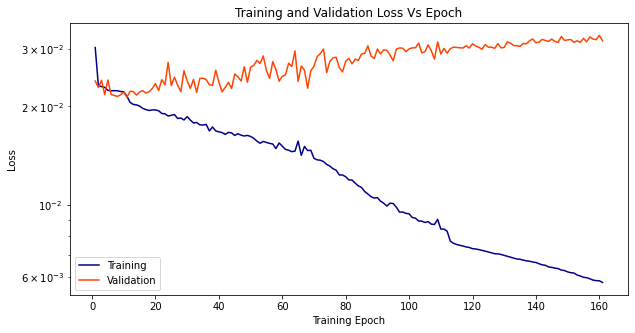

 -> Epoch 1/1000 || LOSS - train: 0.029893, val: 0.022016 | MSE - train: 0.029896, val: 0.022016 | RMSE - train: 0.172906, val: 0.148377 | LR: 1.00e-03
 -> Epoch 20/1000 || LOSS - train: 0.018514, val: 0.019459 | MSE - train: 0.018512, val: 0.019459 | RMSE - train: 0.136058, val: 0.139495 | LR: 1.00e-03
 -> Epoch 40/1000 || LOSS - train: 0.017192, val: 0.019171 | MSE - train: 0.017191, val: 0.019171 | RMSE - train: 0.131116, val: 0.138460 | LR: 1.00e-03
 -> Epoch 60/1000 || LOSS - train: 0.014773, val: 0.019595 | MSE - train: 0.014772, val: 0.019595 | RMSE - train: 0.121540, val: 0.139981 | LR: 1.00e-03
 -> Epoch 80/1000 || LOSS - train: 0.010860, val: 0.018524 | MSE - train: 0.010858, val: 0.018524 | RMSE - train: 0.104204, val: 0.136102 | LR: 1.00e-03
 -> Epoch 100/1000 || LOSS - train: 0.008684, val: 0.020552 | MSE - train: 0.008684, val: 0.020552 | RMSE - train: 0.093189, val: 0.143359 | LR: 1.00e-03
 -> Epoch 120/1000 || LOSS - train: 0.007600, val: 0.020624 | MSE - train: 0.00760

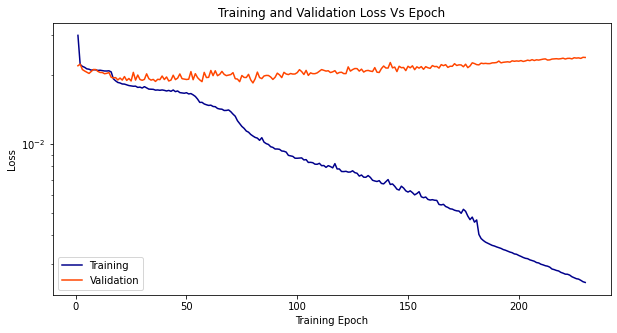

In [5]:
MLP1._train(n_epochs=1000, verbose=20, plot=True)    

Best prediction: 701, Worst prediction: 809


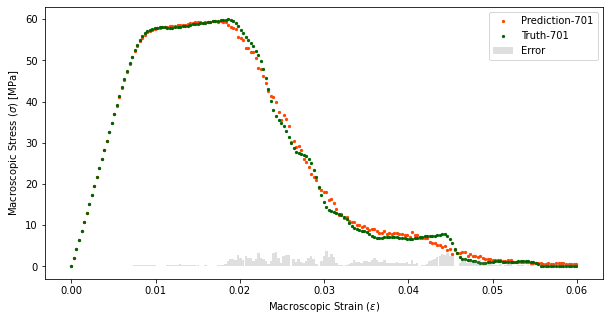

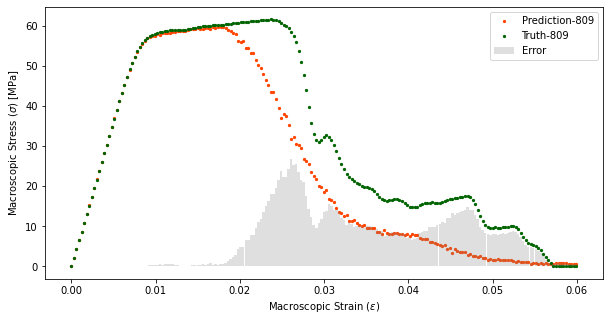

Best prediction: 60, Worst prediction: 319


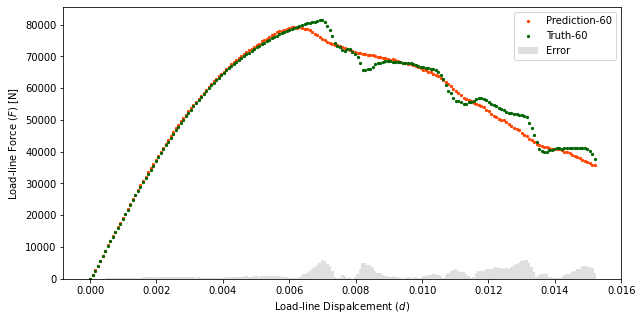

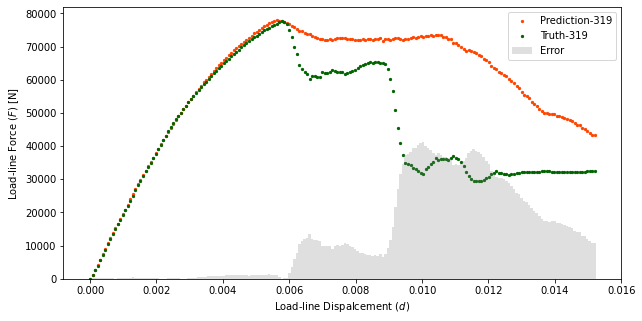

In [6]:
MLP1._predict(test_dataloader=None, plot=True)

## Graph Neural Network (GNN)

In [7]:
DAT = DATA(
    path=1, 
    path_add="",
    load=True, 
    load_split=False,
    split_frac=0.85,
    save_split=False,
    LAT="FCC", 
    dis="disNodes", 
    dN=0.2, 
    mechMode="MULTI",
    nsims=None,
    model="GNN",
    scale=("maxmin", "inout"),
    reduce_dim=False #("PCA", "out", 0.95, 10, True)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

c:\Users\exy053\OneDrive - Queen Mary, University of London\Documents\Research\p1-LatticeFractureToughness\p1git-Lattices\code\resources\lattices.py:672: RuntimeWarning: divide by zero encountered in double_scalars
  return np.array([np.cos(np.arctan([n0[1]/n0[0]]))[0], np.sin(np.arctan([n0[1]/n0[0]]))[0]])


Using device: cpu


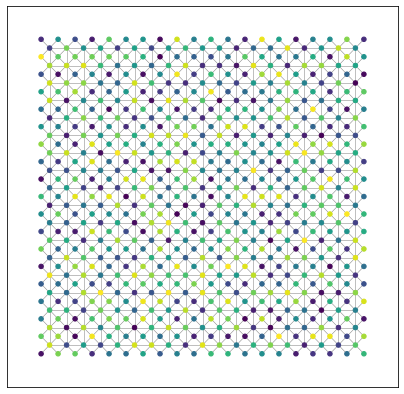

Layer (type:depth-idx)                   Output Shape              Param #
GNN                                      [16, 201]                 --
├─GCNConv: 1-1                           [11552, 4]                4
│    └─Linear: 2-1                       [11552, 4]                8
│    └─SumAggregation: 2-2               [11552, 4]                --
├─LayerNorm: 1-2                         [11552, 4]                8
├─ReLU: 1-3                              [11552, 4]                --
├─Dropout: 1-4                           [11552, 4]                --
├─ModuleList: 1-11                       --                        (recursive)
│    └─gcnBlock: 2-3                     [11552, 8]                --
│    │    └─GCNConv: 3-1                 [11552, 8]                40
│    │    └─LayerNorm: 3-2               [11552, 8]                16
│    │    └─ReLU: 3-3                    [11552, 8]                --
├─Dropout: 1-6                           [11552, 8]                --
├─ModuleL

In [8]:
GNN1 = MODEL(
    typ=DAT.model,
    model=GNN(in_size=DAT.FT_train_in.shape[-1], 
              h_size=[4, 8, 32, 112, 201],
              out_size=DAT.FT_train_out.shape[-1], 
              act="relu",
              block="gcn",
              norm="layer", 
              dropout=0.2).to(device), 
    lossf = nn.MSELoss(reduction="mean"),
    # lossf = [CustomQuantileLoss(quantiles=[0.5, 0.45, 0.1], zone_boundaries=(50, 150), err_type="L2"),
    #          CustomPhysicalRegularizationLoss(delta_tolerance=0.0, epsilon_tolerance=1.0, epsilon_decay=2.0, oscillation_power=2.0, reduction="mean"),
    #          CustomStrainEnergyLoss(x_values=None, fracture_indices=None, reduction="mean")],
    opt=("adam", 0.0), #("adam", 1e-4),
    batch=16,
    lr=1e-3,
    data=DAT,
    mechMode=DAT.mechMode,
    scheduler=("min", 0.2427, 100, 1e-4), 
    earlyStop=EarlyStopping(patience=150, min_delta=1e-4, verbose=True),
    w_init=weights_init,
    device=device
)

GNN1._summary()

 -> Epoch 1/1000 || LOSS - train: 0.037182, val: 0.024671 | MSE - train: 0.037193, val: 0.024671 | RMSE - train: 0.192855, val: 0.157069 | LR: 1.00e-03
 -> Epoch 20/1000 || LOSS - train: 0.021613, val: 0.022832 | MSE - train: 0.021615, val: 0.022832 | RMSE - train: 0.147020, val: 0.151101 | LR: 1.00e-03
 -> Epoch 40/1000 || LOSS - train: 0.021525, val: 0.023558 | MSE - train: 0.021523, val: 0.023558 | RMSE - train: 0.146708, val: 0.153486 | LR: 1.00e-03
 -> Epoch 60/1000 || LOSS - train: 0.021461, val: 0.022381 | MSE - train: 0.021465, val: 0.022381 | RMSE - train: 0.146511, val: 0.149604 | LR: 1.00e-03
 -> Epoch 80/1000 || LOSS - train: 0.021414, val: 0.021910 | MSE - train: 0.021415, val: 0.021910 | RMSE - train: 0.146338, val: 0.148020 | LR: 1.00e-03
 -> Epoch 100/1000 || LOSS - train: 0.021360, val: 0.021905 | MSE - train: 0.021358, val: 0.021905 | RMSE - train: 0.146145, val: 0.148003 | LR: 1.00e-03
 -> Epoch 120/1000 || LOSS - train: 0.021394, val: 0.021993 | MSE - train: 0.02139

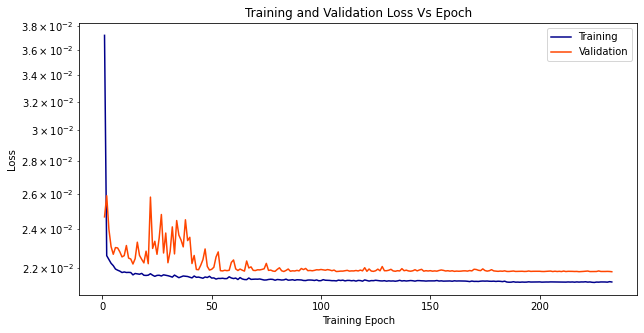

 -> Epoch 1/1000 || LOSS - train: 0.037493, val: 0.023219 | MSE - train: 0.037505, val: 0.023219 | RMSE - train: 0.193662, val: 0.152379 | LR: 1.00e-03
 -> Epoch 20/1000 || LOSS - train: 0.020807, val: 0.021286 | MSE - train: 0.020808, val: 0.021286 | RMSE - train: 0.144249, val: 0.145897 | LR: 1.00e-03
 -> Epoch 40/1000 || LOSS - train: 0.020653, val: 0.022218 | MSE - train: 0.020655, val: 0.022218 | RMSE - train: 0.143720, val: 0.149056 | LR: 1.00e-03
 -> Epoch 60/1000 || LOSS - train: 0.020610, val: 0.020579 | MSE - train: 0.020606, val: 0.020579 | RMSE - train: 0.143549, val: 0.143452 | LR: 1.00e-03
 -> Epoch 80/1000 || LOSS - train: 0.020564, val: 0.020270 | MSE - train: 0.020564, val: 0.020270 | RMSE - train: 0.143403, val: 0.142373 | LR: 1.00e-03
 -> Epoch 100/1000 || LOSS - train: 0.020526, val: 0.020434 | MSE - train: 0.020528, val: 0.020434 | RMSE - train: 0.143277, val: 0.142949 | LR: 1.00e-03
 -> Epoch 120/1000 || LOSS - train: 0.020499, val: 0.020254 | MSE - train: 0.02050

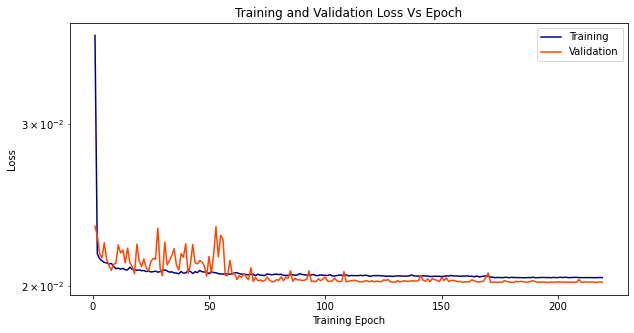

In [9]:
GNN1._train(n_epochs=1000, verbose=20, plot=True)

Best prediction: 885, Worst prediction: 764


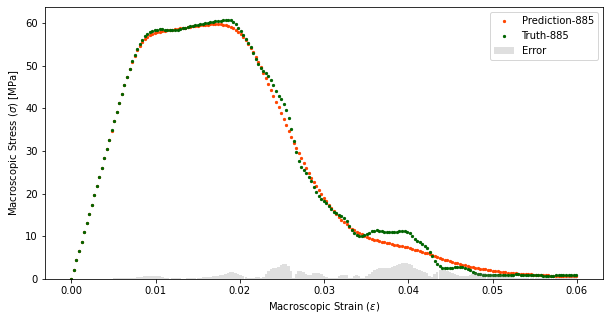

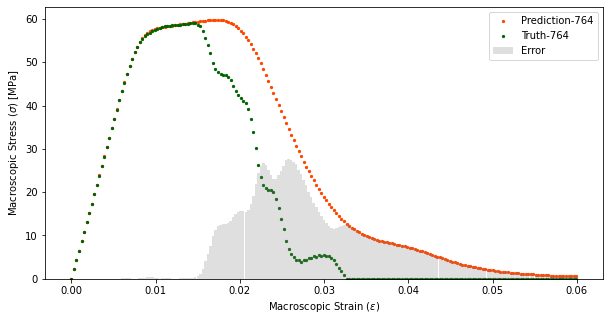

Best prediction: 458, Worst prediction: 68


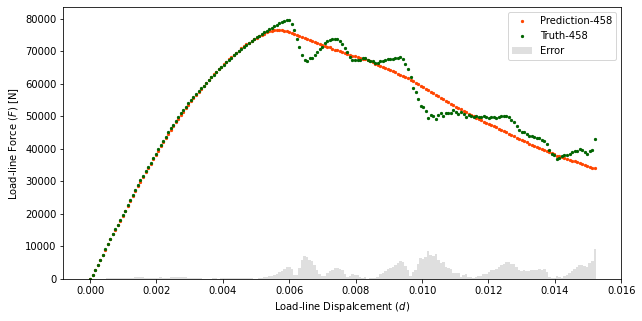

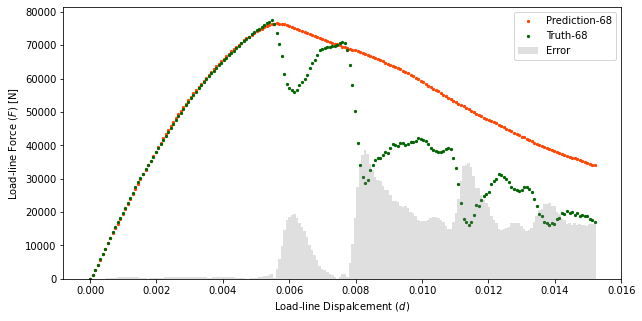

In [10]:
GNN1._predict(test_dataloader=None, plot=True)

In [11]:
# from resources.calculations import calcUT, calcFT

# class CustomPhysicalRegularizationLoss(nn.Module):
#     """
#     Penalizes high point-to-point oscillations in predicted output curves.
#     - Oscillation penalty starts once |y_j - y_{j-1}| exceeds delta_tolerance.
#     - Penalty weight decays after epsilon_tolerance as epsilon increases.
#     """
#     def __init__(
#         self,
#         delta_power=2.0,
#         epsilon_tolerance=1.0,
#         epsilon_decay=2.0,
#         reduction="mean",
#     ):
#         super().__init__()
#         self.epsilon_tolerance = float(epsilon_tolerance)
#         self.epsilon_decay = float(epsilon_decay)
#         self.oscillation_power = float(delta_power)
#         self.reduction = reduction.lower()

#     def _strain_weights(self, n_diffs, y_pred):
#         # Differences are defined between consecutive points; use mid-point epsilon.
#         eps = torch.linspace(0.0, 1.0, steps=n_diffs + 1, device=y_pred.device, dtype=y_pred.dtype)
#         eps_mid = 0.5 * (eps[1:] + eps[:-1])
#         print(eps_mid)
#         weights = torch.where(
#             eps_mid <= self.epsilon_tolerance,
#             torch.ones_like(eps_mid),
#             torch.exp(-self.epsilon_decay * (eps_mid - self.epsilon_tolerance)),
#         )
#         return weights

#     def forward(self, y_pred, y_true, typ):
#         self.delta_tolerance = (y_true.max() - y_true.min()) / 100

#         diffs = torch.abs(y_pred[:, 1:] - y_pred[:, :-1])
#         excess = torch.relu(diffs - self.delta_tolerance)
#         if self.oscillation_power != 1.0:
#             excess = excess ** self.oscillation_power
#         weights = self._strain_weights(diffs.shape[1], y_pred).unsqueeze(0)
#         print(excess.shape, weights.shape)
#         penalty = excess * weights

#         if self.reduction == "sum":
#             return penalty.sum()
#         if self.reduction == "none":
#             return penalty
#         return penalty.mean()

# test = CustomPhysicalRegularizationLoss(delta_power=2.0, epsilon_tolerance=0.4, epsilon_decay=5.0, reduction="mean")

In [12]:
# test(torch.Tensor(DAT.UT_test_out), torch.Tensor(DAT.UT_test_out), "UT")

In [13]:
# class CustomStrainEnergyLoss(nn.Module):
#     """
#     Squared error between integrated predicted and target curves up to fracture index.
#     fracture_indices can be:
#     - None: integrate full curve
#     - 1D tensor/list/ndarray of per-sample indices
#     - callable(batch_size, n_points, device) -> indices
#     """
#     def __init__(self, x_values=None, fracture_indices=None, reduction="mean"):
#         super().__init__()
#         self.fracture_indices = fracture_indices
#         self.reduction = reduction.lower()
#         if x_values is None:
#             self.register_buffer("x_values", torch.tensor([], dtype=torch.float32), persistent=False)
#         else:
#             self.register_buffer("x_values", torch.tensor(x_values, dtype=torch.float32), persistent=False)

#     def _get_fracture_indices(self, batch_size, n_points, device):
#         if self.fracture_indices is None:
#             return torch.full((batch_size,), n_points - 1, dtype=torch.long, device=device)
#         if callable(self.fracture_indices):
#             idx = self.fracture_indices(batch_size=batch_size, n_points=n_points, device=device)
#             return torch.as_tensor(idx, dtype=torch.long, device=device).view(-1)
#         idx = torch.as_tensor(self.fracture_indices, dtype=torch.long, device=device).view(-1)
#         if idx.numel() == 1:
#             idx = idx.repeat(batch_size)
#         if idx.numel() != batch_size:
#             raise ValueError(
#                 f"fracture_indices length ({idx.numel()}) must match batch size ({batch_size}) "
#                 "or be a single scalar."
#             )
#         return idx.clamp(min=0, max=n_points - 1)

#     def _integral_up_to(self, y_row, idx):
#         end = int(idx.item()) + 1
#         if end <= 1:
#             return y_row.new_tensor(0.0)
#         if self.x_values.numel() > 0:
#             if self.x_values.numel() != y_row.numel():
#                 raise ValueError(
#                     f"x_values length ({self.x_values.numel()}) does not match output length ({y_row.numel()})."
#                 )
#             return torch.trapz(y_row[:end], self.x_values[:end].to(y_row.device, y_row.dtype))
#         return torch.trapz(y_row[:end])

#     def forward(self, y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
#         if y_pred.shape != y_true.shape:
#             raise ValueError(f"Shape mismatch: y_pred shape {y_pred.shape} != y_true shape {y_true.shape}")

#         if y_pred.ndim == 1:
#             y_pred = y_pred.unsqueeze(0)
#             y_true = y_true.unsqueeze(0)
#         if y_pred.ndim != 2:
#             raise ValueError(f"Expected 2D tensors [batch, n_points], got ndim={y_pred.ndim}")

#         batch_size, n_points = y_pred.shape
#         fracture_idx = self._get_fracture_indices(batch_size, n_points, y_pred.device)

#         err_sq_terms = []
#         for i in range(batch_size):
#             pred_int = self._integral_up_to(y_pred[i], fracture_idx[i])
#             true_int = self._integral_up_to(y_true[i], fracture_idx[i])
#             err_sq_terms.append((pred_int - true_int) ** 2)
#         err_sq = torch.stack(err_sq_terms)

#         if self.reduction == "sum":
#             return err_sq.sum()
#         if self.reduction == "none":
#             return err_sq
#         return err_sq.mean()

# test1 = CustomStrainEnergyLoss(x_values=None, fracture_indices=None, reduction="mean")

In [14]:
# test1(torch.Tensor(DAT.FT_test_out), torch.Tensor(DAT.FT_test_out))